In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("Salary_Data.csv")


print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape of dataset: (30, 3)

First 5 rows:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
X = df["YearsExperience"]
y = df["Salary"]

X = X.values
y = y.values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (30,)
Shape of y: (30,)


In [4]:
def predict(X, w, b):
    """
    Predict output using linear regression equation:
    y_hat = w * X + b
    """
    return w * X + b


In [5]:
def mean_squared_error(y, y_pred):
    """
    Compute Mean Squared Error (MSE)
    """
    return np.mean((y - y_pred) ** 2)


In [6]:
def compute_gradients(X, y, y_pred):
    """
    Compute gradients of MSE loss w.r.t w and b
    """
    n = len(y)
    
    dw = (-2 / n) * np.sum(X * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)
    
    return dw, db


In [7]:
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.01
epochs = 1000

losses = []

for epoch in range(epochs):
    # Step 1: Prediction
    y_pred = predict(X, w, b)
    
    # Step 2: Compute loss
    loss = mean_squared_error(y, y_pred)
    losses.append(loss)
    
    # Step 3: Compute gradients
    dw, db = compute_gradients(X, y, y_pred)
    
    # Step 4: Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db


In [8]:
print("Final weight (w):", w)
print("Final bias (b):", b)
print("Final loss:", losses[-1])


Final weight (w): 9504.801321957242
Final bias (b): 24474.557566113308
Final loss: 31300502.429962


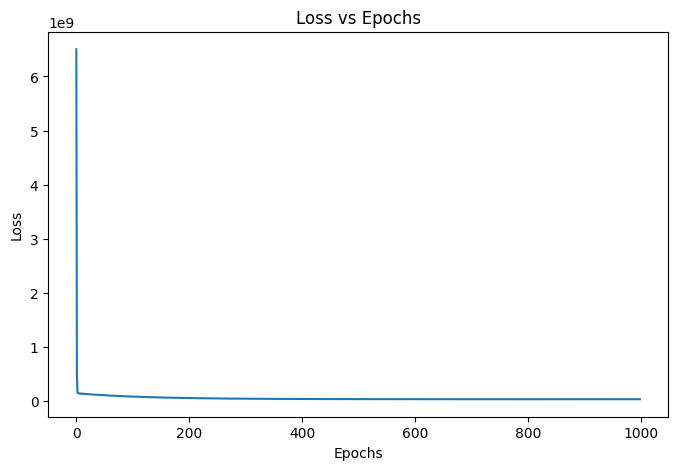

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.show()


c:\Users\talek\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\talek\AppData\Local\Temp\ipykernel_29904\1543577432.py:5: RuntimeWarning: overflow encountered in square
  return np.mean((y - y_pred) ** 2)
c:\Users\talek\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\talek\AppData\Local\Temp\ipykernel_29904\175683182.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  w = w - lr * dw


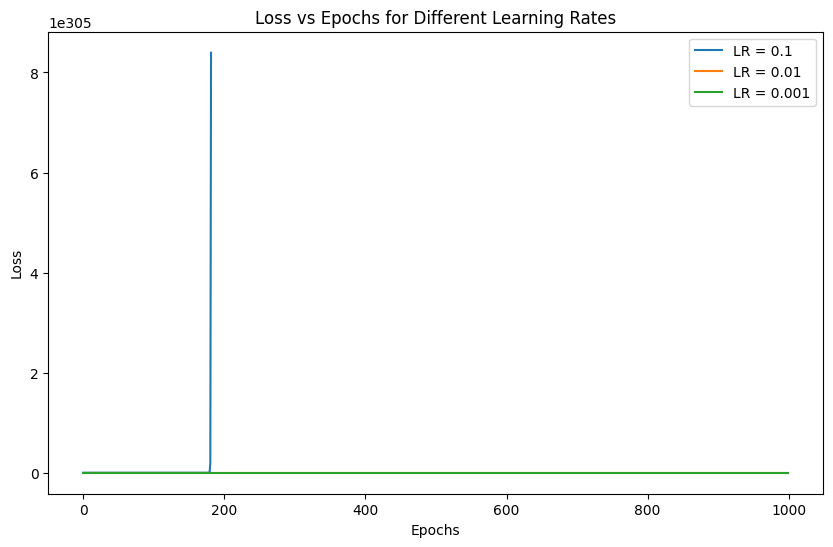

In [10]:
learning_rates = [0.1, 0.01, 0.001]
epochs = 1000

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    w = 0.0
    b = 0.0
    losses_lr = []
    
    for epoch in range(epochs):
        y_pred = predict(X, w, b)
        loss = mean_squared_error(y, y_pred)
        losses_lr.append(loss)
        
        dw, db = compute_gradients(X, y, y_pred)
        w = w - lr * dw
        b = b - lr * db
    
    plt.plot(range(epochs), losses_lr, label=f"LR = {lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs for Different Learning Rates")
plt.legend()
plt.show()


In [15]:
from sklearn.linear_model import LinearRegression

X_sklearn = X.reshape(-1, 1)
sk_model = LinearRegression()
sk_model.fit(X_sklearn, y)

print("Sklearn coefficient (w):", sk_model.coef_[0])
print("Sklearn intercept (b):", sk_model.intercept_)

print("Scratch model weight (w):", w)
print("Scratch model bias (b):", b)


Sklearn coefficient (w): 9449.962321455074
Sklearn intercept (b): 24848.203966523208
Scratch model weight (w): 11684.522618790954
Scratch model bias (b): 9622.991910271252
